In [4]:
import glob
import matplotlib.pyplot as plt, pandas as pd
from collections import defaultdict
from daemon_analysis_tools.file_handling import load_answers_from_yaml

In [5]:
# Load all the processed yaml files 
processed_data = load_answers_from_yaml('/home/sjonathan/Downloads/update/Journal-Research-Data-Policy/data/processed/all_answers/')


RSC/energy_and_environmental_science/data_sharing has inconsistencies: skipped
RSC/energy_and_environmental_science/data_fair has inconsistencies: skipped
RSC/energy_and_environmental_science/data_referee has inconsistencies: skipped
RSC/energy_and_environmental_science/data_recommended has inconsistencies: skipped
RSC/energy_and_environmental_science/data_required has inconsistencies: skipped
RSC/energy_and_environmental_science/code_versioning has inconsistencies: skipped
RSC/energy_and_environmental_science/code_docs has inconsistencies: skipped
Taylor & Francis/journal_of_asian_ceramic_societies/code_required has inconsistencies: skipped


In [6]:
question_answer_dict = defaultdict(list)

for publisher in processed_data.values():
    for journal_results in publisher.values():
        for question, answer in journal_results.items():
            # Use the correct answer
            try:
                int(question)
                print(f"Question: {question} {publisher.keys()}")
            except:
                pass
            question_answer_dict[question].append(answer.correct_answer.text)

# Count the number of times each answer was given
count_dict = {
    question: pd.Series(answers).value_counts()
    for question, answers in question_answer_dict.items()
}
count_publisher = defaultdict(int)
for publisher, _ in processed_data.items():
    for journal_results in _.keys():
#        print(f"{publisher}: {journal_results}")
        count_publisher[publisher]+=1


Question: 1 dict_keys(['smart_materials_and_structures', 'journal_of_physics_condensed_matter', 'ecs_journal_of_solid_state_science_and_technology', 'journal_of_physics_d', 'advances_in_natural_sciences_nanoscience_and_nanotechnology', 'iop_conference_series_materials_science_and_engineering', 'journal_of_physics_photonics', 'chinese_physics_b', 'new_journal_of_physics', 'materials_research_express', 'journal_of_physics_energy', '2d_materials', 'ecs_advances', 'journal_of_semiconductors', 'plasma_sources_science_and_technology', 'nanotechnology', 'quantum_science_and_technology', 'journal_of_the_electrochemical_society'])
Question: 3 dict_keys(['smart_materials_and_structures', 'journal_of_physics_condensed_matter', 'ecs_journal_of_solid_state_science_and_technology', 'journal_of_physics_d', 'advances_in_natural_sciences_nanoscience_and_nanotechnology', 'iop_conference_series_materials_science_and_engineering', 'journal_of_physics_photonics', 'chinese_physics_b', 'new_journal_of_physic

In [15]:
count_dict.keys()

dict_keys(['rdp_exist', 'data_sharing', 'data_fair', 'data_availability', 'data_citability', 'data_timing', 'data_sharing_method', 'data_licenses', 'data_referee', 'data_recommended', 'data_required', 'code_required', 'code_reproducibility', 'code_versioning', 'code_quality', 'code_autotest', 'code_docs', 'code_linting', 'code_development', 1, 3, 4, 2, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20])

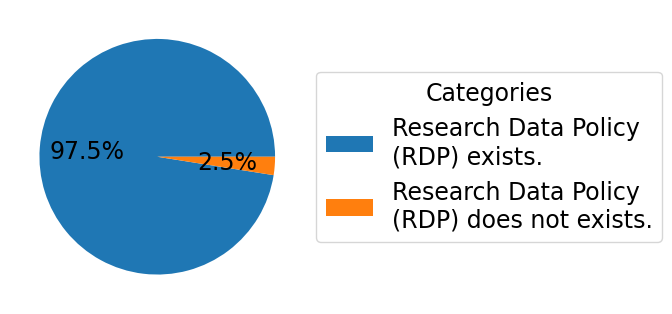

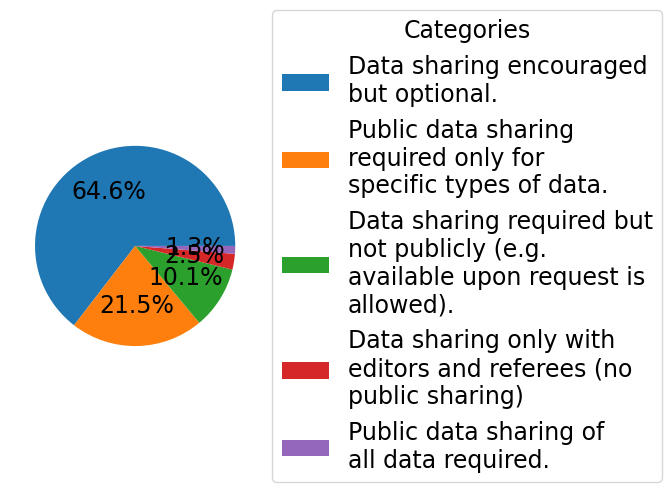

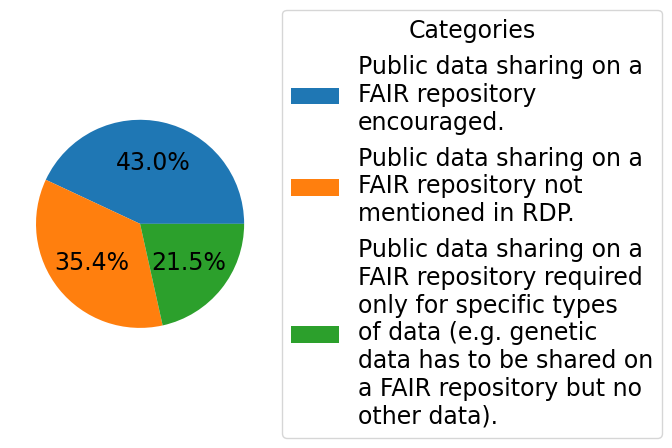

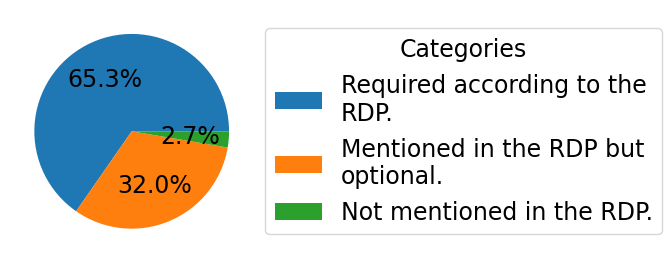

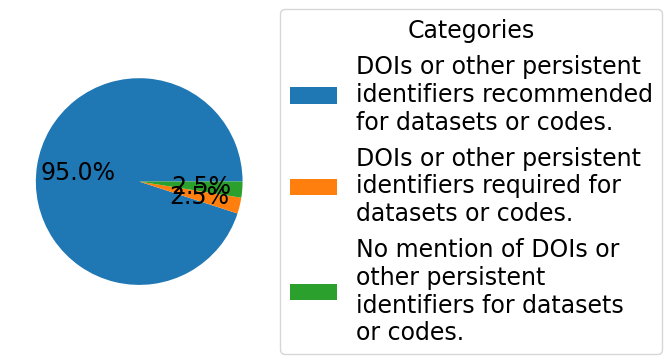

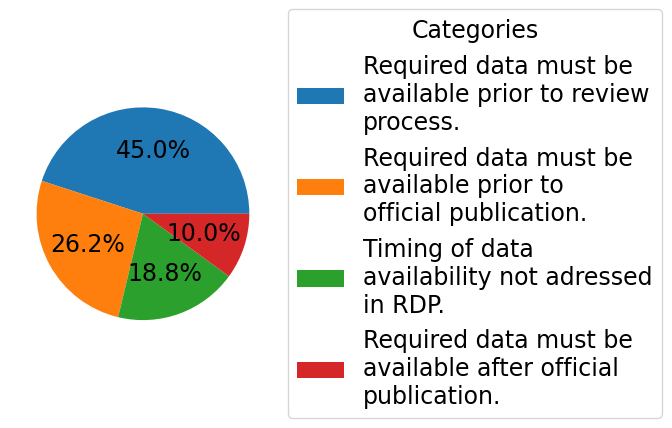

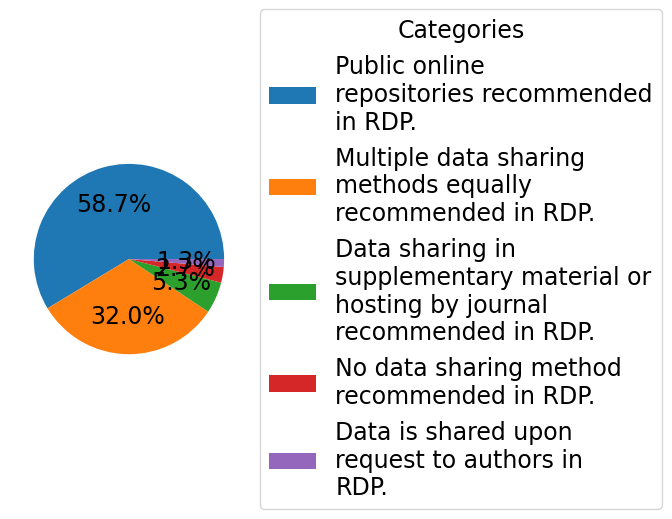

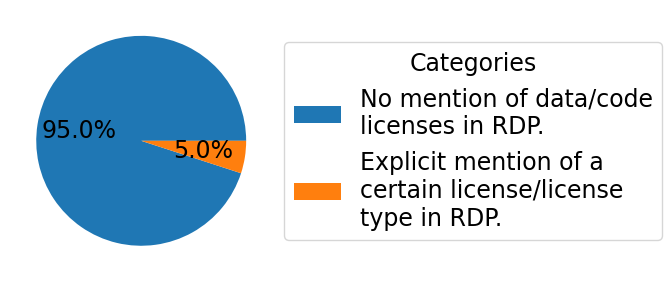

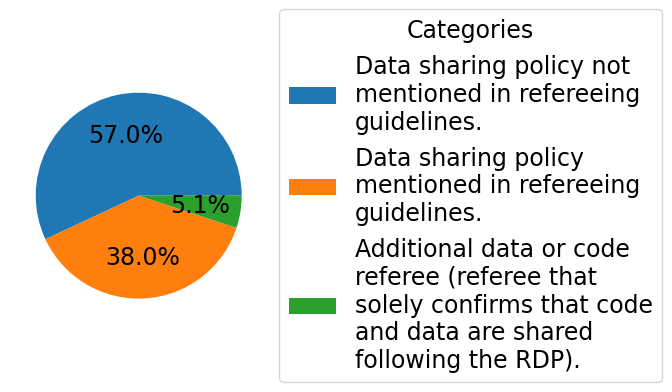

/tmp/ipykernel_3674837/1938124342.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


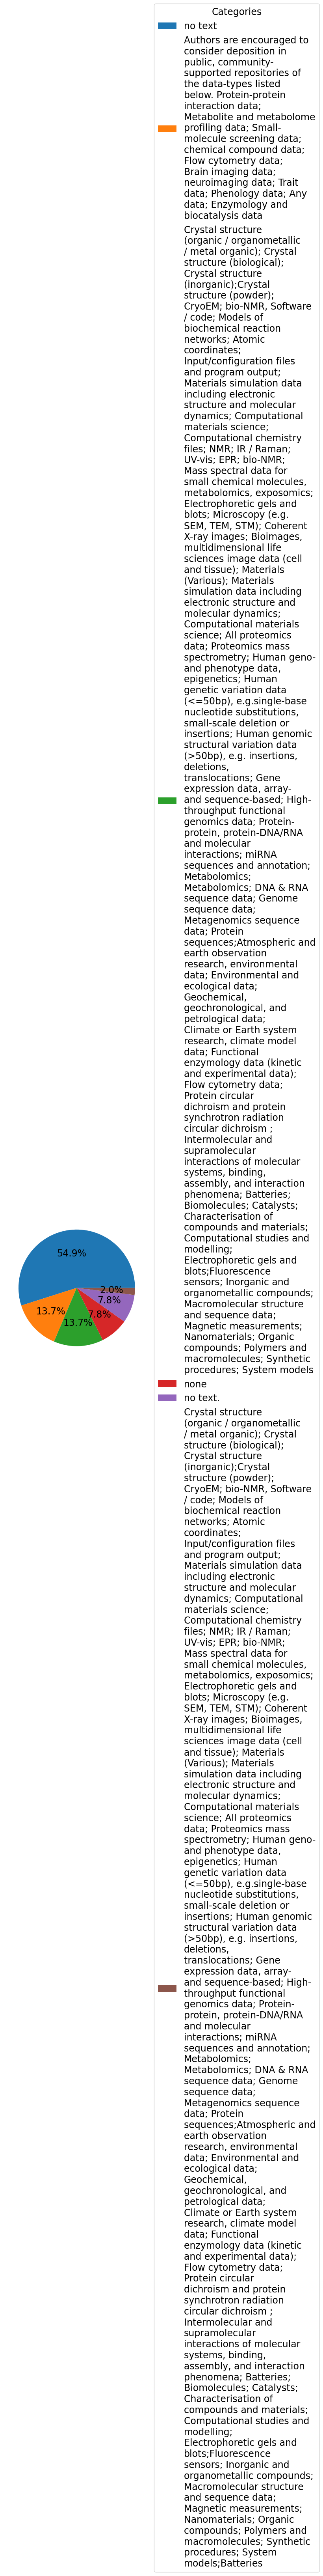

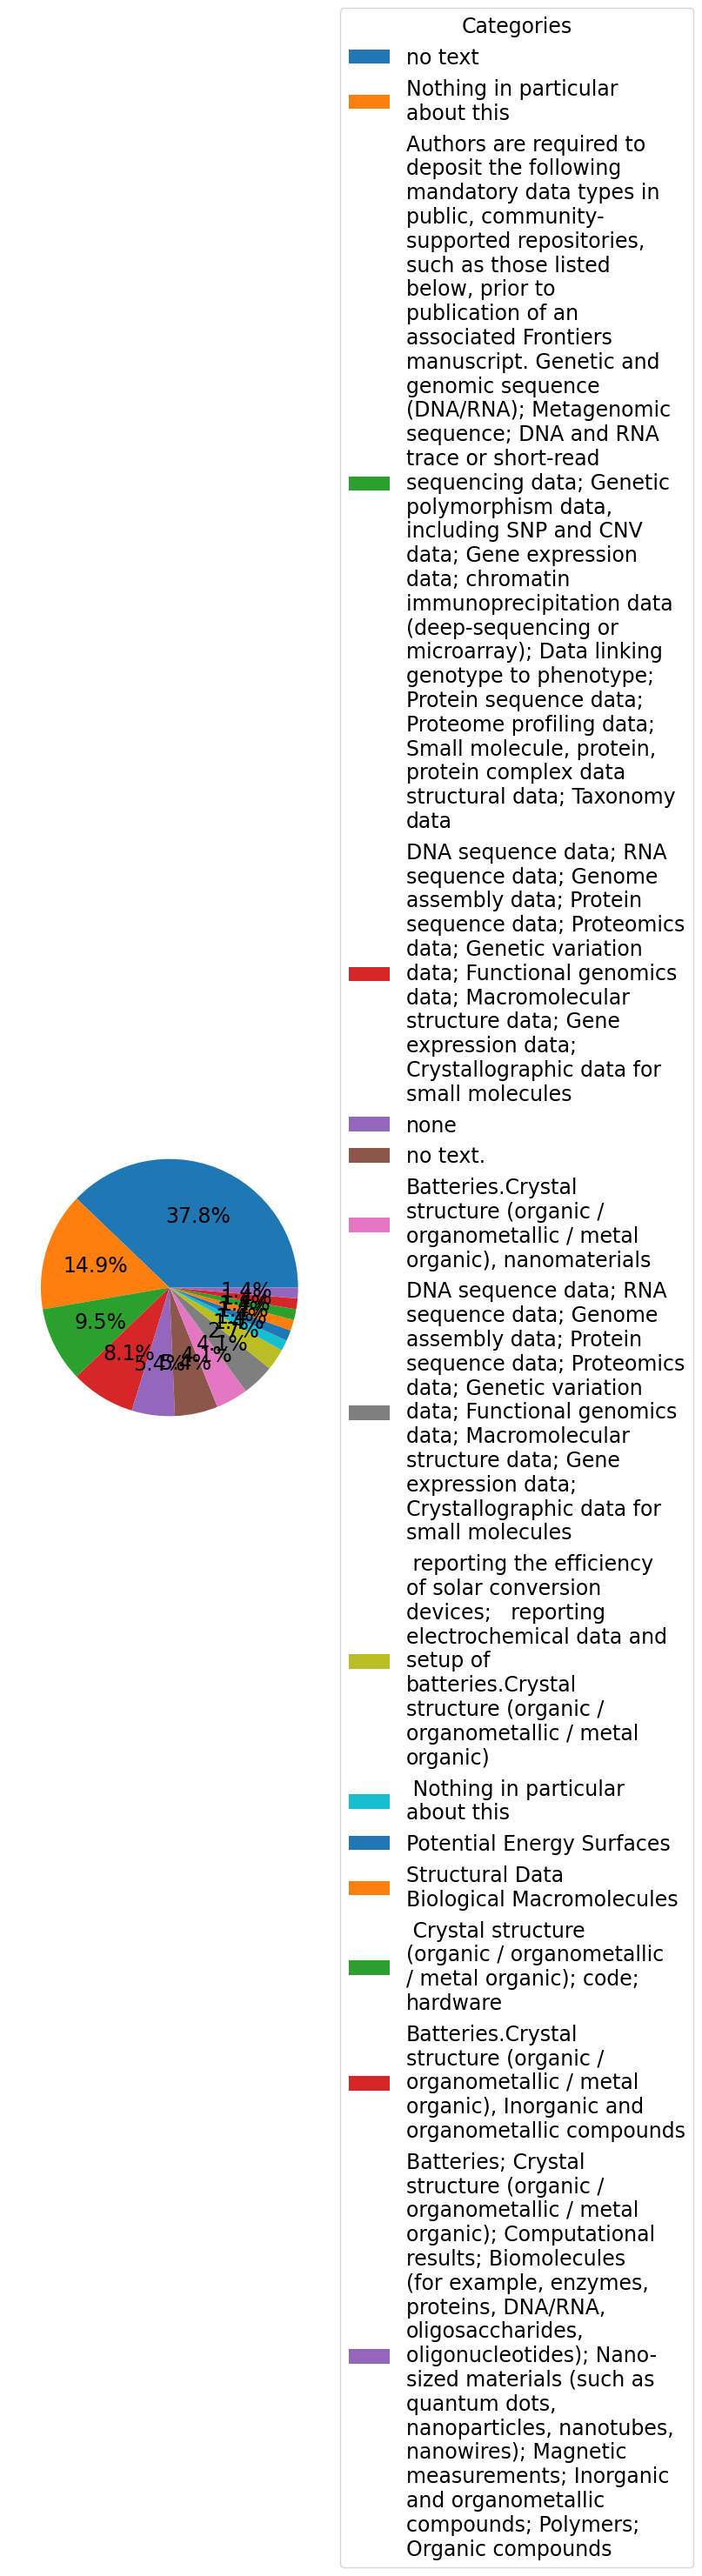

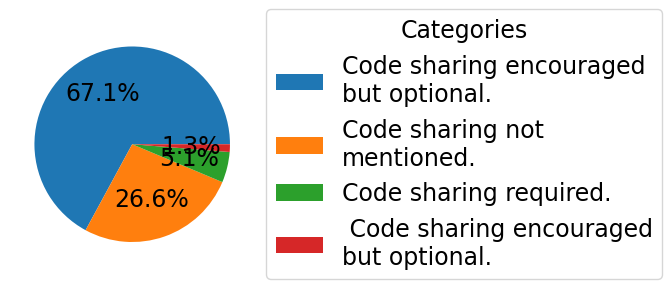

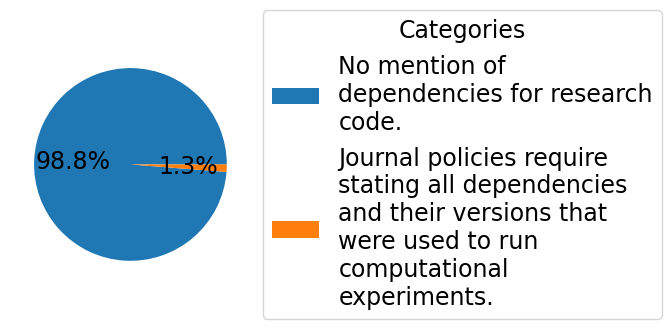

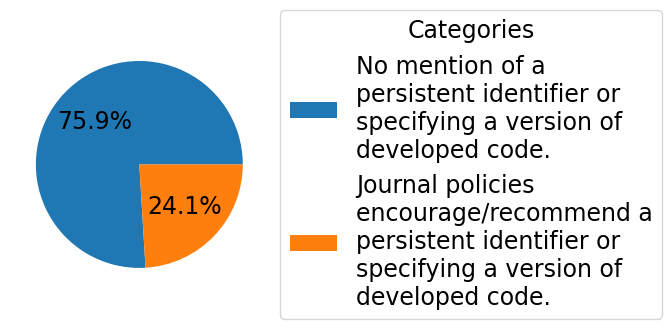

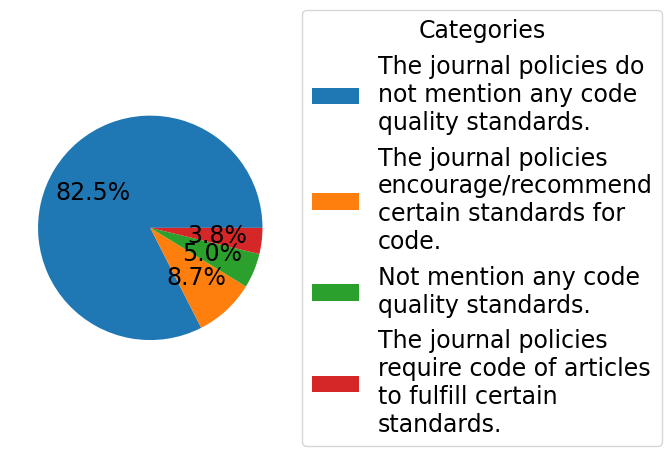

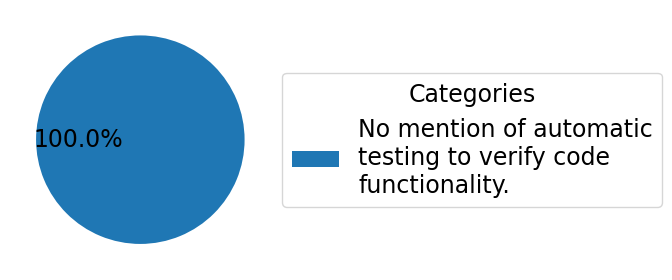

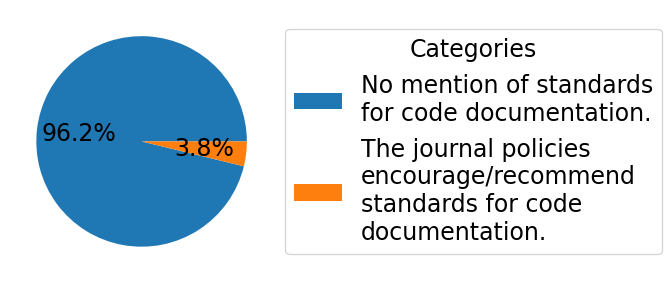

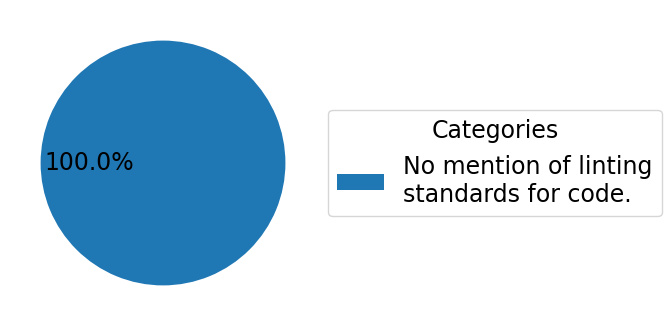

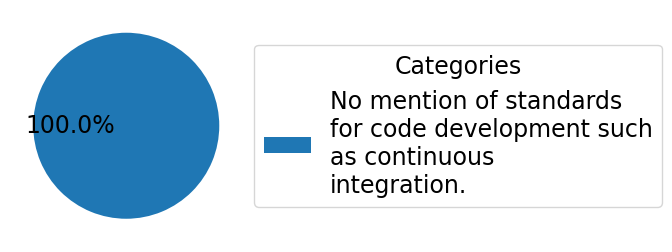

In [20]:
import textwrap

def wrap_labels(labels, max_length=25):
    """Wrap labels to a specified max_length."""
    return ['\n'.join(textwrap.wrap(str(label), max_length)) for label in labels]

for question, counts in count_dict.items():
    plt.figure()
    labels = wrap_labels(list(counts.index))
    wedges, texts, autotexts = plt.pie(counts, labels=["" for _ in labels], autopct='%1.1f%%')
    
    # Create legend instead of displaying labels on pie chart
    plt.legend(wedges, labels, title="Categories", loc="center left", bbox_to_anchor=(1, 0.5))
    
    #plt.title('\n'.join(textwrap.wrap(str(question), 50)))  # Ensure question is a string
    plt.tight_layout()
    plt.show()